In [1]:
import numpy as np
import h5py
import time

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
from helpers.simulation import *
from helpers.qtransform import *
from dataset_generation.gw_class_gen import *
from helpers.config import *
from scipy.stats import truncnorm

import warnings
warnings.filterwarnings("ignore")

In [2]:
plt.rcParams.update({
    "font.size": 15,
    "axes.labelsize": 15,
    "axes.titlesize": 15,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "text.usetex": False,
    "font.family": "serif"
})

## Figure 1

In [3]:
params = np.loadtxt(lpf_ord_param_path, skiprows=1)

lpf_betas = params[:, 0]
lpf_levels = params[:, 1]

bet_min = 1
amp_min, amp_max = 1e-16, 1e-10

lpf_levels = lpf_levels[lpf_betas > bet_min]
lpf_betas = lpf_betas[lpf_betas > bet_min]

lpf_betas = lpf_betas[(lpf_levels > amp_min) & (lpf_levels < amp_max)]
lpf_levels = lpf_levels[(lpf_levels > amp_min) & (lpf_levels < amp_max)]

In [4]:
with h5py.File(glitch_lm_dataset_path, "r") as h5:
    amp_array = h5["amp"][:]
    beta_array = h5["beta"][:]

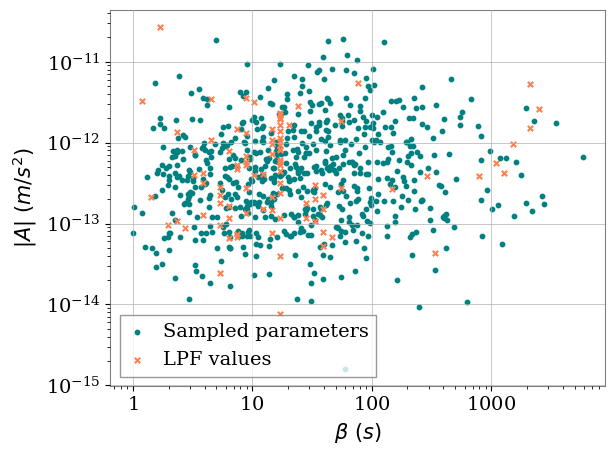

In [5]:
plt.figure(tight_layout=True)
plt.scatter(beta_array, amp_array, color='teal', s=10, label='Sampled parameters')
plt.scatter(lpf_betas, np.abs(lpf_levels), color='coral', s=15, marker='x', label='LPF values')
plt.xscale('log')
plt.yscale('log')
plt.ylabel('$|A|\ (m/s^2)$')
plt.xlabel('$\\beta\ (s)$')
plt.legend()
plt.savefig(DIST/'figures'/'glitch_params.png')
plt.show()

## Figure 2

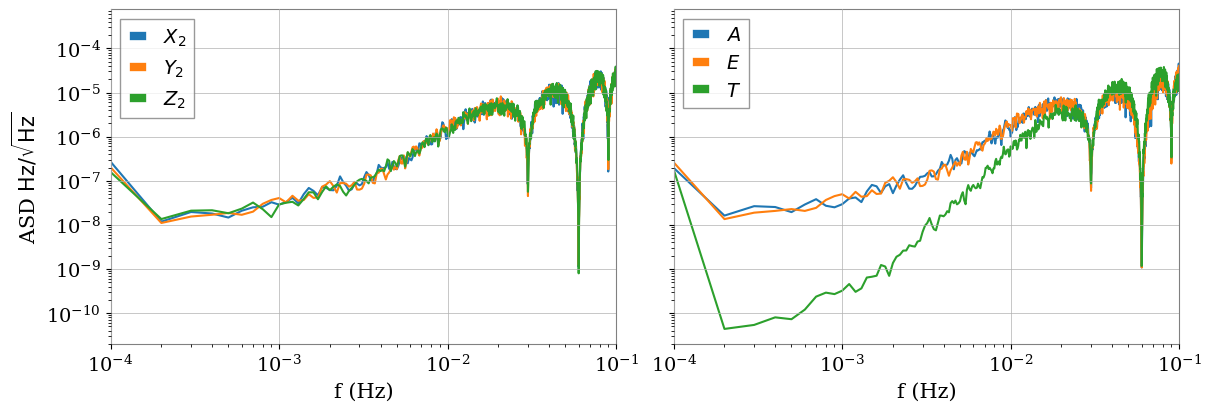

In [17]:
SX_sim = np.load(PSD_PATH / 'psd_X.npz')
SY_sim = np.load(PSD_PATH / 'psd_Y.npz')
SZ_sim = np.load(PSD_PATH / 'psd_Z.npz')

SA_sim = np.load(PSD_PATH / 'psd_A.npz')
SE_sim = np.load(PSD_PATH / 'psd_E.npz')
ST_sim = np.load(PSD_PATH / 'psd_T.npz')

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True, constrained_layout=True)

axes[0].loglog(SX_sim['f_psd'], np.sqrt(SX_sim['psd']), label='$X_2$')
axes[0].loglog(SY_sim['f_psd'], np.sqrt(SY_sim['psd']), label='$Y_2$')
axes[0].loglog(SZ_sim['f_psd'], np.sqrt(SZ_sim['psd']), label='$Z_2$')

axes[1].loglog(SA_sim['f_psd'], np.sqrt(SA_sim['psd']), label='$A$')
axes[1].loglog(SE_sim['f_psd'], np.sqrt(SE_sim['psd']), label='$E$')
axes[1].loglog(ST_sim['f_psd'], np.sqrt(ST_sim['psd']), label='$T$')

axes[0].set_xlabel('f (Hz)')
axes[0].set_ylabel('ASD $\\text{Hz}/\sqrt{\\text{Hz}}$')
axes[0].set_xlim(1e-4, 1e-1)
axes[0].legend()

axes[1].set_xlabel('f (Hz)')
axes[1].set_xlim(1e-4, 1e-1)
axes[1].legend()

plt.savefig(FIGURES / 'noise_psd.png')
plt.show()